<a href="https://colab.research.google.com/github/MatteoTomasetto/SHRED-ROM/blob/main/DrugDiffusionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
# IMPORT LIBRARIES

import torch
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)

##**Drug Diffusion Model**

Consider a drug that is administered to a patient and diffuses between three compartments in the body, that are

1.   Blood (central compartment)
2.   Highly perfused tissues (like liver, kidneys)
3.   Poorly perfused tissues (like fat, muscle)


Let $u_1(t), u_2(t), u_3(t)$ be the amount of drug in each compartment at time $t$.

Let $k_{1 \to 2}, k_{2 \to 1}, k_{1 \to  3}, k_{3 \to 1}$ be the transfer rates between the compartments and let $k_{1 \to 0}$ be the elimination rate from the central compartment.

The system of ODEs describing the drug diffusion is

\
$$
\dot{{\bf u}} =
\begin{bmatrix}
-k_{1 \to 2}-k_{1 \to 3}-k_{1 \to 0}  & k_{2 \to 1} & k_{3 \to 1}
\\
k_{1 \to 2} & -k_{2 \to 1} & 0
\\
k_{1 \to 3} & 0 & -k_{3 \to 1}
\end{bmatrix}
{\bf u}
$$

\
where ${\bf u}(t) = [u_1(t), u_2(t), u_3(t)]^{\top}$.

Let us assume that $k_{1 \to 2} = 0.4$, $k_{2 \to 1} = 0.2$, $k_{1 \to 3} = 0.1$, $k_{3 \to 1} = 0.05$, while we consider a parametric elimination rate $k_{1 \to 0} = \mu$.


The explicit solution of the system is given by

\
$$
\begin{bmatrix}
u_1(t,\mu) \\ u_2(t,\mu) \\ u_3(t,\mu)
\end{bmatrix}
= \sum_{i=1}^3 c_i e^{\lambda_i(\mu) t} \mathbf{v}_i(\mu)
$$

\
where $\lambda_i(\mu)$ and $\mathbf{v}_i(\mu)$ for $i=1,2,3$ are, respectively, the eigenvalues and eigenvectors of the system matrix, while the coefficients $c_1, c_2, c_3$ has to be determined. To this aim, let us assume that a dose $D=1$ of the drug is administered to the central compartment at time $t=0$, that is $u_1(0, \mu) = 1, u_2(0, \mu) = u_3(0, \mu) = 0$. Therefore the coefficients $c_1,c_2,c_3$ are determined by the system

\
$$
\begin{bmatrix}
u_1(0,\mu) \\ u_2(0,\mu) \\ u_3(0,\mu)
\end{bmatrix}
=
\begin{bmatrix}
1 \\ 0 \\ 0
\end{bmatrix}
=
\begin{bmatrix}
| & | & | \\ \mathbf{v}_1(\mu) & \mathbf{v}_2(\mu) & \mathbf{v}_3(\mu) \\ | & | & |
\end{bmatrix}
\begin{bmatrix}
c_1 \\ c_2 \\ c_3
\end{bmatrix}
$$

In [116]:
# DEFINE THE SYSTEM SOLVER

def assembly(mu):
    '''
    Assembly the the three-Compartment drug diffusion model matrix

    Input
        parameter value   (`float`)

    Output
        system matrix     (`np.array[flaot]`, shape: (3, 3))
    '''

    # define transfer rates between compartments
    k12 = 0.4
    k21 = 0.2
    k13 = 0.1
    k31 = 0.05

    # define elimination rate from the central compartment
    k10 = mu

    # define the system matrix
    A = np.array([[-k12 -k13 -k10,  k21,  k31 ],
                  [ k12,           -k21,  0   ],
                  [ k13,            0,   -k31 ]])

    return A


def drug_diffusion(u0, mu, t):
    '''
    Solve the three-compartment drug diffusion model

    Inputs
        initial condition (`np.array[float]`, shape: (3,))
        parameter value   (`float`)
        time vector       (`np.array[float]`, shape: (ntimes,))

    Output
        solution matrix   (`np.array[float]`, shape: (ntimes, 3)
    '''

    u = np.zeros((len(t), len(u0)))   # solution vector
    u[0] = u0                         # initialization

    # assembly system matrix
    A = assembly(mu)

    # compute eigenvalues and eigenvectors of the system matrix
    lambdas, V = np.linalg.eig(A)

    # compute coefficients
    c = np.linalg.solve(V, u0)

    # compute solution
    for i in range(1,len(t)):
      u[i] = np.dot(V, c * np.exp(lambdas * t[i]))

    return u

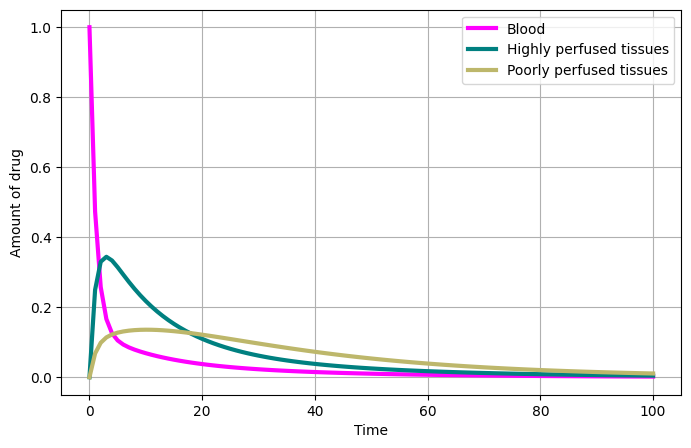

In [117]:
# SOLVE THE SYSTEM FOR A FIXED ELIMINATION RATE

D = 1.0   # initial dose
u0 = np.array([D, 0.0, 0.0])
nstate = len(u0)

mu = 0.3

dt = 1.0
T = 100.0
t = np.arange(0, T + dt, dt)
ntimes = len(t)

u = drug_diffusion(u0, mu, t)

plt.figure(figsize = (8,5))
plt.plot(t, u[:,0], color = 'magenta', linewidth = 3, label = 'Blood')
plt.plot(t, u[:,1], color = 'teal', linewidth = 3, label = 'Highly perfused tissues')
plt.plot(t, u[:,2], color = 'darkkhaki', linewidth = 3, label = 'Poorly perfused tissues')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Amount of drug');
plt.grid(True)

In [118]:
# DATA GENERATION

D = 1.0   # initial dose
u0 = np.array([D, 0.0, 0.0])
nstate = len(u0)

mu_range = [0.0, 1.0]

dt = 1.0
T = 100.0
t = np.arange(0, T + dt, dt)
ntimes = len(t)

# training data generation
ntrajectories = 20
stacked_time = np.tile(t, (ntrajectories, 1))
U = np.zeros((ntrajectories, ntimes, nstate))
mus = np.linspace(mu_range[0], mu_range[1], ntrajectories)

for i in range(ntrajectories):
  U[i] = drug_diffusion(u0, mus[i], t)

# test data generation
ntest = 100
Utest = np.zeros((ntest, ntimes, nstate))
stacked_time_test = np.tile(t, (ntest, 1))
for i in range(ntest):
  mus_test = (mu_range[1] - mu_range[0]) * np.random.rand() + mu_range[0]
  Utest[i] = drug_diffusion(u0, mus_test, t)

In [119]:
# DATA VISUALIZATION

from ipywidgets import interact, FloatSlider

def plot_data(param):

    plt.figure(figsize = (8,5))
    idx = (np.abs(mus - param)).argmin()
    plt.plot(t, U[idx,:,0], color = 'magenta', linewidth = 3, label = 'Blood')
    plt.plot(t, U[idx,:,1], color = 'teal', linewidth = 3, label = 'Highly perfused tissues')
    plt.plot(t, U[idx,:,2], color = 'darkkhaki', linewidth = 3, label = 'Poorly perfused tissues')
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('Amount of drug');
    plt.title(f'Elimination rate {round(param,3)}');
    plt.grid(True)

interact(plot_data, param = FloatSlider(value = mus[0], min = mus[0], max = mus[-1], step = (mus[1]-mus[0]), description='μ', layout={'width': '550px', 'height': '50px'}));

interactive(children=(FloatSlider(value=0.0, description='μ', layout=Layout(height='50px', width='550px'), max…

In [120]:
# TORCH CONVERSION

U = torch.from_numpy(U)
Utest = torch.from_numpy(Utest)

In [121]:
# TRAIN-VALIDATION SPLITTING

split_ratio = 0.8

ntrain = round(split_ratio * ntrajectories)

idx_train = np.random.choice(ntrajectories, size = ntrain, replace = False)
mask = np.ones(ntrajectories)
mask[idx_train] = 0
idx_valid = np.arange(0, ntrajectories)[np.where(mask!=0)[0]]

nvalid = idx_valid.shape[0]

Utrain = U[idx_train]
stacked_time_train = stacked_time[idx_train]
Uvalid = U[idx_valid]
stacked_time_valid = stacked_time[idx_valid]

In [122]:
Uvalid 


tensor([[[1.0000e+00, 0.0000e+00, 0.0000e+00],
         [5.7289e-01, 2.7309e-01, 7.3988e-02],
         [3.6823e-01, 3.8850e-01, 1.1500e-01],
         ...,
         [2.3878e-02, 5.2211e-02, 7.2075e-02],
         [2.3475e-02, 5.1327e-02, 7.0869e-02],
         [2.3079e-02, 5.0459e-02, 6.9683e-02]],

        [[1.0000e+00, 0.0000e+00, 0.0000e+00],
         [4.2018e-01, 2.3664e-01, 6.4360e-02],
         [2.0662e-01, 2.9985e-01, 9.0022e-02],
         ...,
         [7.4811e-04, 1.8419e-03, 5.8534e-03],
         [7.2064e-04, 1.7741e-03, 5.6396e-03],
         [6.9419e-04, 1.7088e-03, 5.4335e-03]],

        [[1.0000e+00, 0.0000e+00, 0.0000e+00],
         [3.2476e-01, 2.1131e-01, 5.7651e-02],
         [1.2946e-01, 2.4715e-01, 7.5019e-02],
         ...,
         [1.8977e-04, 4.8143e-04, 2.4087e-03],
         [1.8193e-04, 4.6148e-04, 2.3093e-03],
         [1.7441e-04, 4.4237e-04, 2.2141e-03]],

        [[1.0000e+00, 0.0000e+00, 0.0000e+00],
         [2.9303e-01, 2.0227e-01, 5.5252e-02],
         [1.

## **SHallow REcurrent Decoder networks-based Reduced Order Modeling (SHRED-ROM)**

Let us assume to have a sensor in the blood measuring the drug amount $u_1$ over time. *SHRED-ROM* aims to reconstruct the temporal evolution of the entire state vector $\mathbf{u}(t, \mu)$ starting from the limited sensor measurements available. In general, *SHRED-ROM* combines a recurrent neural network (LSTM), which encodes the temporal history of sensor values in multiple parametric regimes, and a shallow decoder, which projects the LSTM prediction to the (possibly high-dimensional) state dimension. Note that, in the example at hand, the state dimension is equal to $3$ and the decoder is not stricly needed.  

## Is the sensors-based state reconstruction well-posed?

The coefficients $c_1, c_2, c_3$ in the explicit solution formula may be determined by employing one sensor monitoring $u_1$ over time. Specifically, if we measure $u_1(0,\mu), u_1(1,\mu), u_1(2,\mu)$ in the scenario identified by $\mu$, the linear system

\
$$
\begin{bmatrix}
u_1(0,\mu) \\ u_1(1,\mu) \\ u_1(2,\mu)
\end{bmatrix}  
= \begin{bmatrix}
\mathbf{v}_1(\mu)[0] & \mathbf{v}_2(\mu)[0] & \mathbf{v}_3(\mu)[0]
\\
e^{\lambda_1(\mu)} \mathbf{v}_1(\mu)[0] & e^{\lambda_2(\mu)}\mathbf{v}_2(\mu)[0] & e^{\lambda_3(\mu)}\mathbf{v}_3(\mu)[0]
\\
e^{2\lambda_1(\mu)}\mathbf{v}_1(\mu)[0] & e^{2\lambda_2(\mu)}\mathbf{v}_2(\mu)[0] & e^{2\lambda_3(\mu)}\mathbf{v}_3(\mu)[0]
\end{bmatrix}
\begin{bmatrix}
c_1 \\ c_2 \\ c_3
\end{bmatrix}
$$

\
returns$^\ast$ the coefficients $c_1, c_2, c_3$ and, thus, allows us to compute the evolution of the state vector $\mathbf{u}$.

\
$\ast$ The linear system in the unknowns $c_1, c_2, c_3$ is well-posed only if the dynamical system is observable with respect to the sensor measurments, i.e. if the observability matrix

\
$$
O = \begin{bmatrix}
C \\ C A \\ C A^2
\end{bmatrix}
$$

\
is full-rank, where $C$ is the output matrix ($C = [1,0,0]$ in the example at hand since we measure the first state component) and $A$ is the dynamical system matrix.

In [123]:
# CHECK OBSERVABILITY

mu = 0.3
A = assembly(mu)

C = [1, 0, 0]
O = np.array([C, np.dot(C, A), np.dot(C, A*A)])
if np.linalg.matrix_rank(O) == nstate:
    print('The system is observable')
else:
    print('The system is not observable')

The system is observable


In [124]:
# DEFINE FUNCTION TO PROCESS DATA

class TimeSeriesDataset(torch.utils.data.Dataset):
    '''
    Define a dataset of input-output time-series

    Inputs
        sequence of input measurements    (`torch.Tensor[float]`, shape: (ntrajectories, ntimes, ninput))
        state measurements                (`torch.Tensor[float]`, shape: (ntrajectories, ntimes, noutput))

    Output
        Torch dataset                     (`torch.utils.data.Dataset`)
    '''

    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        self.len = X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

    def __len__(self):
        return self.len


def Padding(data, lag):
    '''
    Extract time-series of lenght equal to lag from longer time series in data

    Inputs
        time-series data          (`torch.Tensor[float]`, shape: (ntrajectories, ntimes, ninput))
        lag parameter             (`int`)

    Input
        lagged time-series data   (`torch.Tensor[float]`, shape: (ntrajectories * ntimes, lag, ninput))
    '''

    data_out = torch.zeros(data.shape[0] * data.shape[1], lag, data.shape[2])

    for i in range(data.shape[0]):
        for j in range(1, data.shape[1] + 1):
            if j < lag:
                data_out[i * data.shape[1] + j - 1, -j:] = data[i, :j]
            else:
                data_out[i * data.shape[1] + j - 1] = data[i, j - lag : j]

    return data_out

In [136]:
# DEFINE lstm deepOnet MODEL

class lstm_deepONet(torch.nn.Module):

    def __init__(self, input_size , output_size, hidden_size = 64, hidden_layers = {'branch':2, 'trunk':2}, dropout = 0.1, basis_functions = 10, activation = torch.nn.ReLU()):
        '''
        Deeponet arcitecture for time series data. 
        In branch net is a lstm network
        Trunk netwrok is a simple feedforward network 
        Inputs
            input size  for branch and trunk                    (`dict`)
        	output size (e.g. full-order variable dimension)    (`int`)
        	size hidden layers                          (`int`)
        	number of hidden layers                        (`int`)
        	list of decoder layers sizes                        (`list[int]`)
        	dropout parameter                                   (`float`)
            activation                                          ('function')
        '''

        super(lstm_deepONet,self).__init__()

        # create lstm branch net for handling sequential data 
        self.branch_lstm = torch.nn.LSTM(input_size = input_size['branch'],
                                  hidden_size = hidden_size,
                                  num_layers = hidden_layers['branch'],
                                  batch_first=True)
        # encode lstm network
        self.branch_encoder = torch.nn.Linear(hidden_size, basis_functions * output_size)
        
        # layers in trunk network 
        layers = []
            
        layers.append(torch.nn.Linear(input_size['trunk'], hidden_size))
        layers.append(activation)
        
        for _ in range(hidden_layers['trunk'] - 1):
            layers.append(torch.nn.Linear(hidden_size, hidden_size))
            
            layers.append(activation)
        
        layers.append(torch.nn.Linear(hidden_size, basis_functions * output_size) )
        
        self.trunk = torch.nn.Sequential(*layers) #simple FNN 
        
        # store variables for later use 
        self.hidden_layers = hidden_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.basis_functions = basis_functions
        
    def forward(self, trunk_input, branch_input):
        batch_size = branch_input.size(0)
        device = branch_input.device

        h_0 = torch.zeros(self.hidden_layers['branch'], batch_size, self.hidden_size, device=device) 
        c_0 = torch.zeros(self.hidden_layers['branch'], batch_size, self.hidden_size, device=device) 

        _, (output_branch, _) = self.branch_lstm(branch_input, (h_0, c_0))
        output_branch = self.branch_encoder(output_branch[-1])  # last layer's hidden state
        output_branch = output_branch.view(-1, self.basis_functions, self.output_size) #reshape for innerproduct

        trunk_input = trunk_input.view(batch_size, -1) 
        output_trunk = self.trunk(trunk_input)
        output_trunk = output_trunk.view(-1, self.basis_functions, self.output_size) #reshape for innerproduct

        out = torch.sum(output_trunk * output_branch, dim=1)
        return out


    def freeze(self):

        self.eval()

        for param in self.parameters():
            param.requires_grad = False

    def unfreeze(self):

        self.train()

        for param in self.parameters():
            param.requires_grad = True


In [137]:
# DEFINE TRAINING FUNCTION
from torch.utils.data import DataLoader
from copy import deepcopy
from IPython.display import clear_output as clc
from torch.optim.lr_scheduler import StepLR
from utils.processdata import mse, mre, num2p

mse = lambda datatrue, datapred: (datatrue - datapred).pow(2).sum(axis = -1).mean()  # Mean Squared Error



def fit_deepONet(model, train_dataset, valid_dataset=None, batch_size=64, epochs=50,
        optim=torch.optim.Adam, lr=1e-3, loss_fun=mre, loss_output=mre,
         verbose=False, patience=5, step_size = 50, device='cpu'):

    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    optimizer = optim(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=step_size, gamma=0.1)
    
    train_error_list = []
    valid_error_list = []
    patience_counter = 0
    best_params = deepcopy(model.state_dict())

    model.to(device)

    for epoch in range(1, epochs + 1):

        model.train()
        for batch in train_loader:
            # unpack branch, trunk, and target
            (trunk_input, branch_input), y = batch  
            trunk_input = trunk_input.to(device)
            branch_input = branch_input.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            outputs = model(trunk_input, branch_input)
            # print(np.shape(outputs), np.shape(y))
            loss = loss_fun(outputs, y)
            loss.backward()
            optimizer.step()

        # evaluation
        model.eval()
        scheduler.step()

        with torch.no_grad():
            if valid_dataset is not None:
                train_error = loss_output(train_dataset.Y.to(device), model(train_dataset.trunk_data, train_dataset.branch_data))
                valid_error = loss_output(valid_dataset.Y.to(device), model(valid_dataset.trunk_data, valid_dataset.branch_data))
            else:
                train_error = loss_output(train_dataset.Y.to(device), model(train_dataset.trunk_data, train_dataset.branch_data))
                valid_error = train_error

            train_error_list.append(train_error.item())
            valid_error_list.append(valid_error.item())

        # verbose
        if verbose:
            print(f"Epoch {epoch}: Train Loss = {train_error}, Valid Loss = {valid_error}, learning rate = {scheduler.get_last_lr()[0]}")

        # early stopping
        if valid_error == min(valid_error_list):
            patience_counter = 0
            best_params = deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if patience_counter >= patience:
            model.load_state_dict(best_params)
            if verbose:
                print("Early stopping triggered")
            break

    model.load_state_dict(best_params)
    return train_error_list, valid_error_list

In [138]:
# EXTRACT SENSORS DATA

idx_sensor = 0
nsensors = 1
time = np.linspace(0, T, 101)
sensors_data_train = Utrain[:,:,idx_sensor]
sensors_data_valid = Uvalid[:,:,idx_sensor]
sensors_data_test = Utest[:,:,idx_sensor]

In [139]:
np.shape(U)

torch.Size([20, 101, 3])

In [140]:
device = 'cpu'
lag = 25
# Trunk input: sequences of sensors
train_branch = Padding(sensors_data_train.unsqueeze(2), lag).to(device)  # (num_samples, lag, 1)
valid_branch = Padding(sensors_data_valid.unsqueeze(2), lag).to(device)
test_branch = Padding(sensors_data_test.unsqueeze(2), lag).to(device)

# Branch input: e.g., stacked time
train_trunk = torch.tensor(stacked_time_train, dtype=torch.float32).view(-1, 1).to(device)  # (num_samples, 1)
valid_trunk = torch.tensor(stacked_time_valid, dtype=torch.float32).view(-1, 1).to(device)
test_trunk = torch.tensor(stacked_time_test, dtype=torch.float32).view(-1, 1).to(device)

train_data_out = Padding(Utrain, 1).squeeze(1).to(device)
valid_data_out = Padding(Uvalid, 1).squeeze(1).to(device)
test_data_out = Padding(Utest, 1).squeeze(1).to(device)

In [141]:
print(np.shape(train_trunk))
print(np.shape(train_branch))

torch.Size([1616, 1])
torch.Size([1616, 25, 1])


In [142]:
from torch.utils.data import Dataset, DataLoader
import torch

class BranchTrunkDataset(Dataset):
    """
    PyTorch Dataset for DeepONet or branch/trunk networks.
    
    Each item is ((trunk_input, branch_input), target)
    """
    def __init__(self, trunk_data, branch_data, targets):
        """
        trunk_data: torch.Tensor of shape (N, trunk_features)
        branch_data: torch.Tensor of shape (N, branch_features)
        targets: torch.Tensor of shape (N, output_features)
        """
        assert len(trunk_data) == len(branch_data) == len(targets), \
            "Trunk, branch, and targets must have the same number of samples."
        
        self.trunk_data = trunk_data
        self.branch_data = branch_data
        self.Y = targets

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        trunk_input = self.trunk_data[idx]
        branch_input = self.branch_data[idx]
        target = self.Y[idx]
        
        return (trunk_input, branch_input), target

In [143]:
train_dataset = BranchTrunkDataset(train_trunk, train_branch, train_data_out)
valid_dataset = BranchTrunkDataset(valid_trunk, valid_branch, valid_data_out)
test_dataset = BranchTrunkDataset(test_trunk, test_branch, test_data_out)


In [144]:
train_dataset.Y

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.7836e-01, 1.9796e-01, 5.4107e-02],
        [9.8544e-02, 2.2213e-01, 6.7836e-02],
        ...,
        [5.3329e-04, 1.3240e-03, 4.6755e-03],
        [5.1302e-04, 1.2736e-03, 4.4985e-03],
        [4.9352e-04, 1.2250e-03, 4.3282e-03]])

In [145]:
lstm_DON = lstm_deepONet(input_size={'branch':1, 'trunk':1}, output_size=3, hidden_size = 64, hidden_layers= {'branch':2, 'trunk':2}, dropout = 0.1, activation=torch.nn.ReLU(), basis_functions= 4)

In [149]:
train_errors, valid_errors  = fit_deepONet(lstm_DON, train_dataset, valid_dataset, batch_size = 64, epochs = 200, lr = 1e-5, verbose = True, patience = 50, step_size=100)

Epoch 1: Train Loss = 5.680246353149414, Valid Loss = 5.438053607940674, learning rate = 1e-05
Epoch 2: Train Loss = 3.2536797523498535, Valid Loss = 3.1101808547973633, learning rate = 1e-05
Epoch 3: Train Loss = 2.968540906906128, Valid Loss = 2.8403658866882324, learning rate = 1e-05
Epoch 4: Train Loss = 2.586088180541992, Valid Loss = 2.4742419719696045, learning rate = 1e-05
Epoch 5: Train Loss = 2.823366165161133, Valid Loss = 2.6982908248901367, learning rate = 1e-05
Epoch 6: Train Loss = 2.87909197807312, Valid Loss = 2.750340223312378, learning rate = 1e-05
Epoch 7: Train Loss = 4.166366100311279, Valid Loss = 3.9836788177490234, learning rate = 1e-05
Epoch 8: Train Loss = 1.8115280866622925, Valid Loss = 1.7382664680480957, learning rate = 1e-05
Epoch 9: Train Loss = 4.808534145355225, Valid Loss = 4.595496654510498, learning rate = 1e-05
Epoch 10: Train Loss = 2.3160617351531982, Valid Loss = 2.2161641120910645, learning rate = 1e-05
Epoch 11: Train Loss = 2.730786800384521

KeyboardInterrupt: 

In [147]:
y_pred = lstm_DON.forward(test_dataset.trunk_data, test_dataset.branch_data)
mse(test_dataset.Y, y_pred)

tensor(0.0052, grad_fn=<MeanBackward0>)

torch.Size([10100, 3])


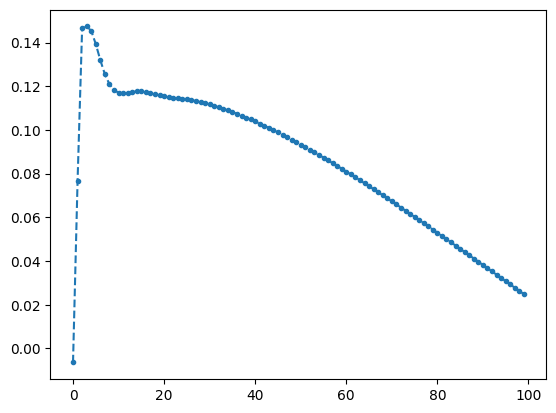

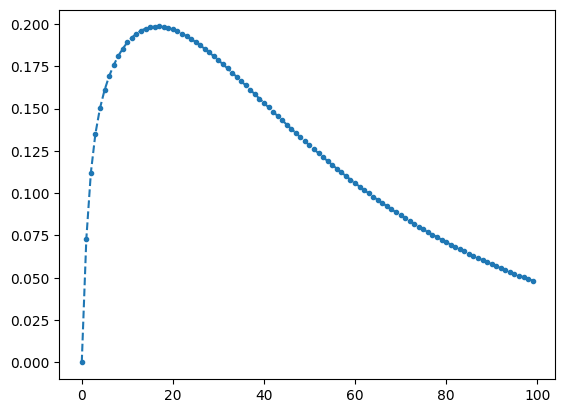

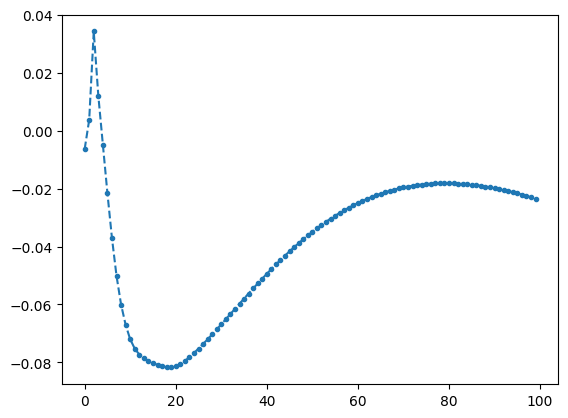

In [148]:
comp = 2
print(np.shape(test_dataset.Y))
plt.plot(test_dataset.trunk_data[:100], y_pred.detach().numpy()[:100,comp], '.--')

plt.figure()
plt.plot(test_dataset.trunk_data[:100], test_dataset.Y[:100,comp], '.--')

plt.figure()
plt.plot(test_dataset.trunk_data[:100], y_pred.detach().numpy()[:100,comp] - test_dataset.Y[:100,comp].numpy(), '.--')

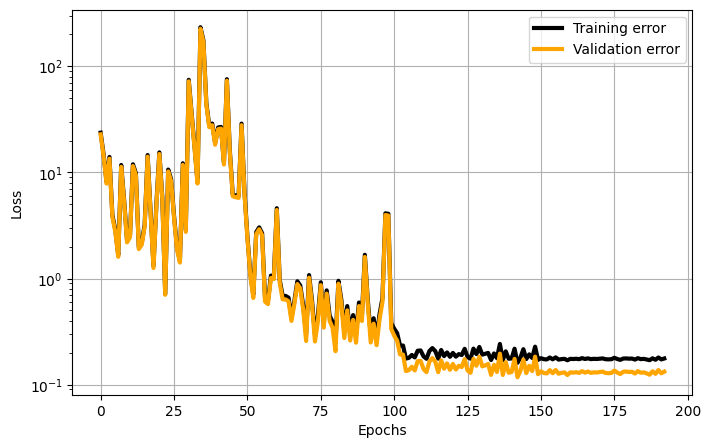

In [97]:
# TRAINING HISTORY VISUALIZATION

plt.figure(figsize = (8,5))
plt.plot(train_errors, 'k', linewidth = 3, label = 'Training error')
plt.plot(valid_errors, 'orange', linewidth = 3, label = 'Validation error')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

In [98]:
# BUILD TRAIN, VALIDATION AND TEST DATASETS WITH PADDING

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lag = 25

train_data_in = Padding(sensors_data_train.unsqueeze(2), lag).to(device)
valid_data_in = Padding(sensors_data_valid.unsqueeze(2), lag).to(device)
test_data_in = Padding(sensors_data_test.unsqueeze(2), lag).to(device)

train_data_out = Padding(Utrain, 1).squeeze(1).to(device)
valid_data_out = Padding(Uvalid, 1).squeeze(1).to(device)
test_data_out = Padding(Utest, 1).squeeze(1).to(device)

train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

In [99]:
print(np.shape(Utrain))
print(np.shape(train_data_in))
print(np.shape(train_dataset.X))
print(np.shape(train_data_out))
print(np.shape(train_dataset.Y))

torch.Size([16, 101, 3])
torch.Size([1616, 25, 1])
torch.Size([1616, 25, 1])
torch.Size([1616, 3])
torch.Size([1616, 3])


In [106]:
# SHRED TRAINING
from utils.models import SHRED, fit
shred = SHRED(nsensors, nstate, hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device)
train_errors, valid_errors = fit(shred, train_dataset, valid_dataset, batch_size = 64, epochs = 150, lr = 1e-3, verbose = True, patience = 100, step_size = 100)

Training done: Training loss = 17.78% 	 Validation loss = 15.53%       	 learning rate = 0.000101


In [107]:
y_pred = shred.forward(test_dataset.X)
mse(test_dataset.Y, y_pred)

tensor(3.2360e-05, grad_fn=<MeanBackward0>)

torch.Size([10100, 3])


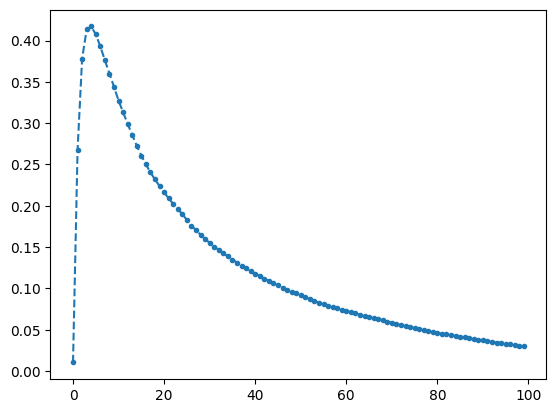

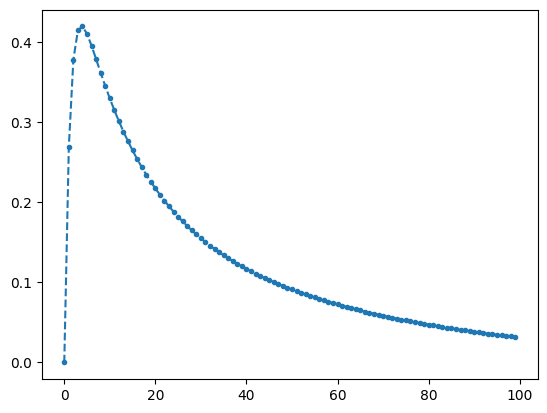

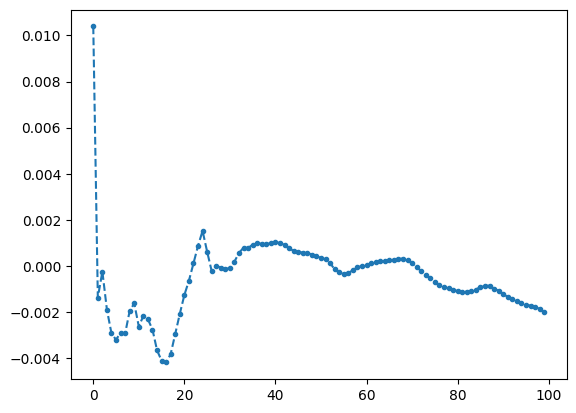

In [108]:
comp = 1
print(np.shape(test_dataset.Y))
plt.plot(stacked_time_test.flatten()[:100], y_pred.detach().numpy()[:100,comp], '.--')

plt.figure()
plt.plot(stacked_time_test.flatten()[:100], test_dataset.Y[:100,comp], '.--')

plt.figure()
plt.plot(stacked_time_test.flatten()[:100], y_pred.detach().numpy()[:100,comp] - test_dataset.Y[:100,comp].numpy(), '.--')

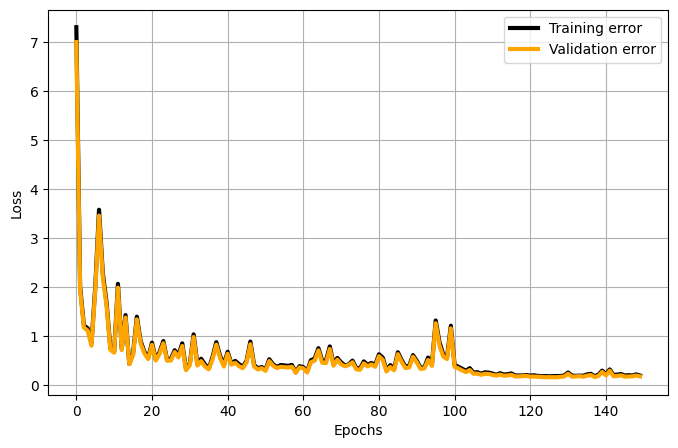

In [109]:
# TRAINING HISTORY VISUALIZATION

plt.figure(figsize = (8,5))
plt.plot(train_errors, 'k', linewidth = 3, label = 'Training error')
plt.plot(valid_errors, 'orange', linewidth = 3, label = 'Validation error')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [38]:
# SHRED RECONSTRUCTION VISUALIZATION

from ipywidgets import interact, IntSlider
import matplotlib.lines as mlines

shred.freeze()

Utest_hat = shred(test_data_in).cpu().reshape(ntest, ntimes, nstate)

def plot_shred_reconstruction(which_test_trajectory):

    plt.figure(figsize = (8,5))
    plt.plot(t, Utest[which_test_trajectory,:,0], color = 'magenta', linewidth = 1, label = 'Blood')
    plt.plot(t, Utest[which_test_trajectory,:,1], color = 'teal', linewidth = 1, label = 'Highly perfused tissues')
    plt.plot(t, Utest[which_test_trajectory,:,2], color = 'darkkhaki', linewidth = 1, label = 'Poorly perfused tissues')
    plt.plot(t, Utest_hat[which_test_trajectory,:,0], color = 'magenta', linestyle = '--', linewidth = 3, label = r'$u_1$ reconstruction')
    plt.plot(t, Utest_hat[which_test_trajectory,:,1], color = 'teal', linestyle = '--', linewidth = 3, label = r'$u_2$ reconstruction')
    plt.plot(t, Utest_hat[which_test_trajectory,:,2], color = 'darkkhaki', linestyle = '--', linewidth = 3, label = r'$u_3$ reconstruction')
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('Amount of drug');
    plt.title(f'Test case {which_test_trajectory}');
    plt.grid(True)

interact(plot_shred_reconstruction, which_test_trajectory = IntSlider(value = 0, min = 0, max = ntest - 1, description='Test case', layout={'width': '550px', 'height': '50px'}));

interactive(children=(IntSlider(value=0, description='Test case', layout=Layout(height='50px', width='550px'),…